In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   -- ------------------------------------- 2.1/40.2 MB 9.8 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/40.2 MB 10.1 MB/s eta 0:00:04
   ------ --------------------------------- 6.6/40.2 MB 10.3 MB/s eta 0:00:04
   -------- ------------------------------- 8.7/40.2 MB 10.1 MB/s eta 0:00:04
   ---------- ----------------------------- 10.7/40.2 MB 10.2 MB/s eta 0:00:03
   ------------ --------------------------- 12.8/40.2 MB 10.2 MB/s eta 0:00:03
   -------------- ------------------------- 14.9/40.2 MB 10.0 MB/s eta 0:00:03
   ---------------- ----------------------- 16.5/40.2 MB 9.6 MB/s eta 0:00:03
   ----------------- ---------------------- 17.8/40.2 MB 9.4 MB/s eta 0:00:03
   ------------------- -------------------- 19.4/40.2 MB 9.2 MB/s eta 0:00:03
   -------------------- ------------------- 20.7/40.2 MB 8.9 MB/s eta 0:00:03
   --------------------- ------------------ 22.0/40.2 MB 8.6 MB/s eta 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.3 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.3 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.5 which is incompatible.


Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.
Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6108 - loss: 1.3884 - val_accuracy: 0.7800 - val_loss: 0.5738
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7438 - loss: 0.5636 - val_accuracy: 0.6400 - val_loss: 0.5766
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7931 - loss: 0.4894 - val_accuracy: 0.8000 - val_loss: 0.5454
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7931 - loss: 0.4560 - val_accuracy: 0.8200 - val_loss: 0.5920
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8128 - loss: 0.4339 - val_accuracy: 0.8000 - val_loss: 0.5512
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
Tumor Detected


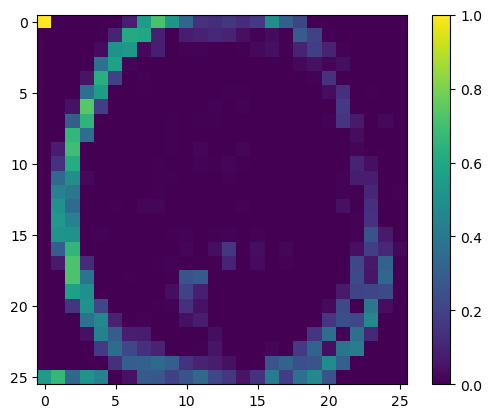

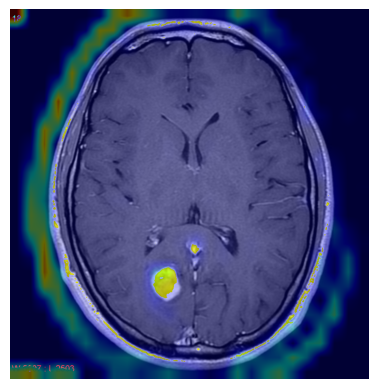

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2

img_size = (224,224)
batch_size = 32

# ------------------ DATASET ------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/keert/Downloads/archive (1)/brain_tumor_dataset",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=123
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/keert/Downloads/archive (1)/brain_tumor_dataset",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=123
)

# ------------------ NORMALIZATION ------------------
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# ------------------ MODEL (FUNCTIONAL API) ------------------
inputs = keras.Input(shape=(224,224,3))

x = layers.Conv2D(32,(3,3),activation='relu')(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64,(3,3),activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128,(3,3),activation='relu')(x)
x = layers.MaxPooling2D()(x)

# save last conv layer
last_conv_layer = x

x = layers.Flatten()(x)
x = layers.Dense(128,activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1,activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ------------------ TRAIN ------------------
model.fit(train_ds, validation_data=test_ds, epochs=5)

# ------------------ PREDICTION ------------------
img_path = "C:/Users/keert/Downloads/archive (1)/yes/Y6.jpg"

img = keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0) / 255

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

# ------------------ GRAD-CAM ------------------

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[last_conv_layer, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)

# display heatmap
plt.imshow(heatmap)
plt.colorbar()
plt.show()

# ------------------ OVERLAY ------------------
img = cv2.imread(img_path)

heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()